In [45]:
import random

import matplotlib.pyplot as plt
import numpy as np
from helpers import generate_torus_adj_matrix

# Random Walks

In this exercise you will implement a simple random walk on a torus graph and will check its convergence to uniform distribution.

Torus is a 2D-grid graph and looks like a 'doughnout', as shown in the picture below. 
<div style="text-align: center;">
  <img src="torus_topology.png" alt="Centered image" style="width: 400px;">
</div>

**Note:** We will use the networkx library to generate our graph. You can install this using

```bash
    pip3 install --upgrade --user networkx
```

Let's generate the probability matrix $\mathbf{G}$ of a torus graph of size $4\times 4$, note that we include self-loops too. You can play around with the code in the helpers.py to generate different graphs.

In [16]:
n_nodes = 25
A = generate_torus_adj_matrix(n_nodes)
G = A/5

Implement random walk on a torus.

In [32]:
def random_walk(G, num_iter):
    ''' 
    Performs num_iter steps of a random walk on a graph with graph transition matrix G, starting from the initial position at node 1.
    
    Arguments:
        G: matrix of probabilities
        num_iter: maximum iterations
    Returns:
        positions: an array of integer positions in a graph at each iteration
    '''
    pos = 0
    positions = [pos]
    for t in range(0, num_iter):
        # fill in here code to jump to random neighbor
        neighbors = np.array(np.where(G[pos,:]!=0)).reshape(-1)
        pos = random.choice(neighbors)
        positions.append(pos)
    return positions

Now we will estimate probability distribution at each iteration. For this we will perform random walk on a graph 100 times and calculate how frequently we visited each node at each iteration.

In [33]:
num_iter = 15
num_repeat = 100 * 1000
frequencies = np.zeros((num_iter + 1, n_nodes))
for _ in range(num_repeat):
    positions = random_walk(G, num_iter)
    frequencies[np.arange(len(positions)), np.array(positions)] += 1
frequencies /= num_repeat

Lets plot our distribution at the last step.

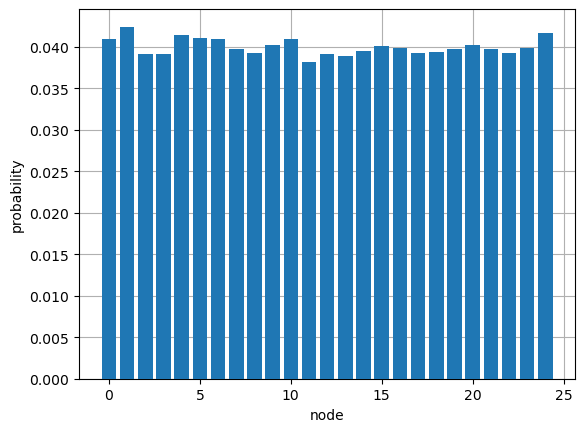

In [36]:
plt.bar(np.arange(n_nodes), frequencies[-1], zorder=3)
plt.xlabel("node")
plt.ylabel("probability")
plt.grid()
plt.show()

You can see that the final disctribution is indeed uniform. Lets now plot how fast did the algorithm converge. For this you need to compute errors $||x_{t} - \mu||_2^2$ at each iteration, where $x_{t}$ is a distribution at step $t$ and $\mu$ is a uniforly distributed vector.

In [58]:
errors = []
mu = np.ones(n_nodes) / n_nodes
for i in range(frequencies.shape[0]):
    error = np.pow(np.linalg.norm( frequencies[i] - mu ), 2)
    errors.append(error)

Lets now plot how fast did the algorithm converge. We will use logarithmic scale on y-axis to be able to distinguish between sublinear and linear rates.

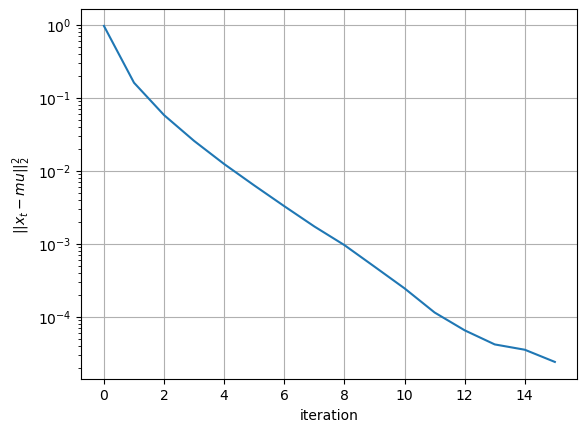

In [59]:
plt.semilogy(errors)
plt.xlabel("iteration")
plt.ylabel("$||x_{t} - mu||_2^2$")
plt.grid()
plt.show()